# Spectral interferometry regression: the matrix-based demodulator

**Source:** G. Pu and B. Jalali, "Neural network enabled time stretch spectral
regression," *Opt. Express* 29(13), 20786-20794 (2021), UCLA Jalali lab --
the paper behind `dgs/nn_spectral_regression.py`'s "Paper [3]" citation in
`dgs/sbir_portfolio.py`'s P7 (Photonic AI Receiver) proposal.

**The physical setup.** A broadband pulse is split into a signal arm and a
reference arm (Mach-Zehnder interferometer); the reference is delayed by
$\tau$ (the "shear"). The two arms recombine and interfere, producing a
spectral fringe pattern

$$S(\omega) = |E_{\rm test}(\omega)|^2 + |E_{\rm ref}(\omega)|^2
+ 2\,\mathrm{Re}\!\left[E_{\rm test}(\omega)\,E_{\rm ref}^*(\omega)\,e^{i\omega\tau}\right].$$

Recovering $E_{\rm test}(\omega)$ -- both magnitude and phase -- from $S(\omega)$
alone is "spectral regression." The paper trains a 5-layer neural network to do
this directly from raw interferograms and shows it beats the classical
**Hilbert-transform demodulator** (its baseline, section 2.4). **This notebook
implements and tests that classical baseline** (`dgs/spectral_interferometry.py`),
reusing `dgs/causality.py`'s FFT-based Hilbert transform along the spectral axis
-- the SAME analytic-signal matrix machinery already in this repo, applied to a
different axis. The paper's own trained network is NOT reimplemented here; see
the honesty note in Part 6.

**Why this is a DIFFERENT setup from this repo's usual GS pipeline.**
`dgs/gs_core.py` and `dgs/nn_spectral_regression.py` recover phase from TWO
DISPERSED INTENSITY measurements ($I_1,I_2$ from two different $H(f)=e^{i\pi Df^2}$
dispersions). This notebook's setup is ONE interferogram from a signal+delayed-
reference interferometer -- a genuinely different measurement, not a renaming.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root (notebook runs in notebooks/)
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
sp.init_printing()

from dgs.spectral_interferometry import (
    minimum_phase_from_log_magnitude, random_causal_profile,
    spectral_interferogram, valid_tau_range, hilbert_demodulate,
    quantize_enob, demodulation_rmse_vs_enob, spectral_regression_output_size,
)
from dgs.causality import hilbert_transform
from dgs.photonic_vs_electronic_delay import dispersion_induced_delay_spread_s
print("loaded dgs.spectral_interferometry")

loaded dgs.spectral_interferometry


## Part 1 -- Causal (Kramers-Kronig) test profiles

The paper trains and tests on profiles that are "digitally generated" but
"obey causality by satisfying the Kramers-Kronig relation" (abstract). This
repo already has ONE Kramers-Kronig pair in `dgs/causality.py`
($\mathrm{Re}\,\chi \leftrightarrow \mathrm{Im}\,\chi$, the optical
susceptibility form). The paper's profiles need a DIFFERENT pair: log-magnitude
$\leftrightarrow$ phase -- the **Bode gain-phase relation** for a causal,
minimum-phase system,
$$\phi(\omega) = -\mathcal H[\ln|E(\omega)|](\omega).$$
Same Hilbert-transform machinery, different pair of quantities -- not the same
relation restated (see `dgs/spectral_interferometry.py`'s docstring for the
distinction).

**What would I actually measure in a lab?** The paper modulates a real
Waveshaper (a programmable spectral filter) with these profiles and measures
the resulting interferogram on a real detector -- the synthetic profiles below
stand in for that hardware step.

**MATLAB equivalent:** `hilbert(x)` gives the analytic signal directly (its
imaginary part is $\mathcal H[x]$); `real(hilbert(log_mag))`'s negative is the
Bode-relation phase used here.

**Questions to ask:** Does a LARGER log-magnitude ripple amplitude produce a
LARGER phase excursion (they're linked by the same Hilbert transform, so yes)?
Is the zero-ripple (flat spectrum) case exactly zero phase (a flat, real,
positive spectrum has no phase to reconstruct)?

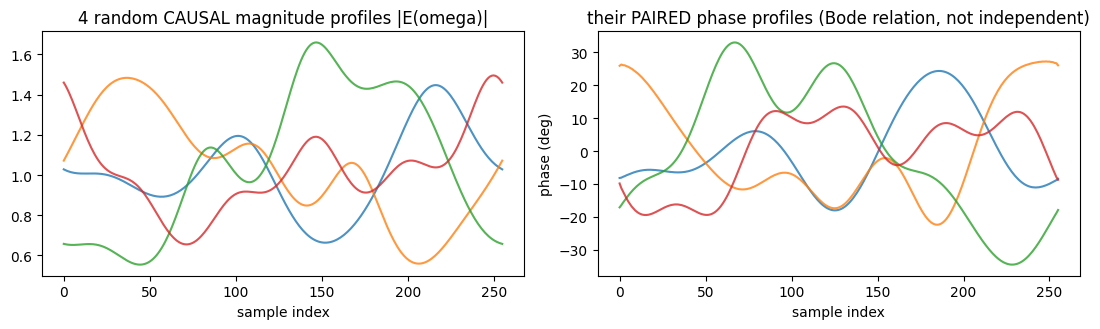

each (magnitude, phase) pair is causally linked -- the phase is NOT free to choose
independently of the magnitude, exactly the constraint dgs/causality.py's
kramers_kronig_real/imag enforce for a different pair of quantities.


In [2]:
rng1 = np.random.default_rng(0)
n1 = 256

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
for _ in range(4):
    magnitude, phase = random_causal_profile(n1, rng1, n_harmonics=5, log_mag_amplitude=0.5)
    axs[0].plot(magnitude, alpha=0.8)
    axs[1].plot(np.degrees(phase), alpha=0.8)
axs[0].set_title('4 random CAUSAL magnitude profiles |E(omega)|'); axs[0].set_xlabel('sample index')
axs[1].set_title('their PAIRED phase profiles (Bode relation, not independent)'); axs[1].set_xlabel('sample index')
axs[1].set_ylabel('phase (deg)')
plt.tight_layout(); plt.show()
print("each (magnitude, phase) pair is causally linked -- the phase is NOT free to choose")
print("independently of the magnitude, exactly the constraint dgs/causality.py's")
print("kramers_kronig_real/imag enforce for a different pair of quantities.")

In [3]:
# sanity check: flat (zero-ripple) log-magnitude -> exactly zero phase
flat_log_mag = np.zeros(n1)
flat_phase = minimum_phase_from_log_magnitude(flat_log_mag)
print(f"flat spectrum: max|phase| = {np.max(np.abs(flat_phase)):.2e} rad  (should be ~0)")

flat spectrum: max|phase| = 0.00e+00 rad  (should be ~0)


## Part 2 -- Forward model: the spectral interferogram

$$S(\omega) = |E_{\rm test}|^2 + |E_{\rm ref}|^2
+ 2\,\mathrm{Re}\!\left[E_{\rm test}\,E_{\rm ref}^*\,e^{i\omega\tau}\right]$$

**Sign convention matters here, concretely.** `numpy.fft.fft` uses the
$e^{-i2\pi kn/N}$ convention, which fixes WHICH FFT bin the $e^{i\omega\tau}$
cross term lands in. Get the sign wrong (relative to the demodulator in Part 3)
and you silently recover $\overline{E_{\rm test}}$ instead of $E_{\rm test}$ --
the conjugate-ambiguity failure mode `dgs/nn_spectral_regression.py` exists to
fight, reintroduced here by an FFT sign mismatch rather than GS's inherent
ambiguity. `dgs/spectral_interferometry.py`'s two functions are a matched
sign pair for exactly this reason (see its docstrings).

**What would I actually measure in a lab?** $S(\omega)$ is exactly what a
grating spectrometer or the time-stretch spectrometer records (Fig. 1 of the
paper) -- a single real-valued trace, with no direct access to phase.

**MATLAB equivalent:** straightforward elementwise complex arithmetic
(`S = abs(Et).^2 + abs(Er).^2 + 2*real(Et.*conj(Er).*exp(1i*omega*tau));`).

**Questions to ask:** Does the fringe SPACING in $S(\omega)$ increase or
decrease as $\tau$ grows (increases -- more delay means faster oscillation in
$\omega$, exactly the quefrency-domain shift Part 3 exploits)?

valid tau range for this omega grid: [21.9, 397.4]


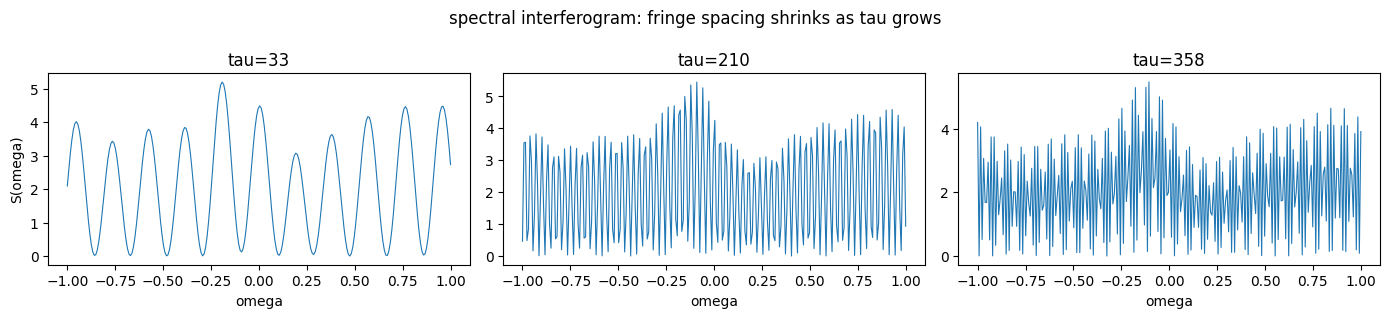

In [4]:
n2 = 256
omega2 = np.linspace(-1.0, 1.0, n2)
tau_min2, tau_max2 = valid_tau_range(omega2)
print(f"valid tau range for this omega grid: [{tau_min2:.1f}, {tau_max2:.1f}]")

rng2 = np.random.default_rng(1)
magnitude2, phase2 = random_causal_profile(n2, rng2)
E_test2 = magnitude2 * np.exp(1j * phase2)
E_ref2 = np.ones(n2, dtype=complex)   # flat, unit-amplitude, zero-phase reference

fig, axs = plt.subplots(1, 3, figsize=(14, 3.2))
for tau2, ax in zip([tau_min2 * 1.5, (tau_min2 + tau_max2) / 2, tau_max2 * 0.9], axs):
    S2 = spectral_interferogram(E_test2, E_ref2, omega2, tau2)
    ax.plot(omega2, S2, lw=0.8)
    ax.set_title(f'tau={tau2:.0f}'); ax.set_xlabel('omega')
axs[0].set_ylabel('S(omega)')
plt.suptitle('spectral interferogram: fringe spacing shrinks as tau grows')
plt.tight_layout(); plt.show()

## Part 3 -- Hilbert-transform demodulation (reproduces the paper's Fig. 2)

The classical baseline (paper section 2.4): filter out the slowly-varying
background, form the **analytic signal** via a Hilbert transform (reusing
`dgs/causality.py`'s FFT-based `hilbert_transform` -- SAME matrix machinery as
the Kramers-Kronig work in Part 1, applied along $\omega$ instead of $t$), then
strip the known $\tau$-carrier and divide out the known reference field:

$$\hat E_{\rm test}(\omega) = \frac{\left(S_{\rm ac}+i\mathcal H[S_{\rm ac}]\right)\,e^{-i\omega\tau}}{2\,E_{\rm ref}^*(\omega)}.$$

**What would I actually measure in a lab?** The paper compares this exact
demodulation against ground truth (the profile actually programmed into the
Waveshaper) -- reproduced here with `magnitude2/phase2` as the known ground
truth instead of a lab-measured one.

**MATLAB equivalent:** `hilbert(S_ac)` gives the analytic signal in one call
(MATLAB's `hilbert` already returns $x+i\mathcal H[x]$, unlike NumPy which
has no built-in equivalent -- hence `dgs/causality.py`'s own implementation).

**Questions to ask:** Is the recovered magnitude/phase visually indistinguishable
from ground truth (paper's Fig. 2 shows the Hilbert baseline visibly departs
from ground truth under fiber nonlinearity -- our synthetic model has no such
nonlinearity, so recovery should be much closer here)?

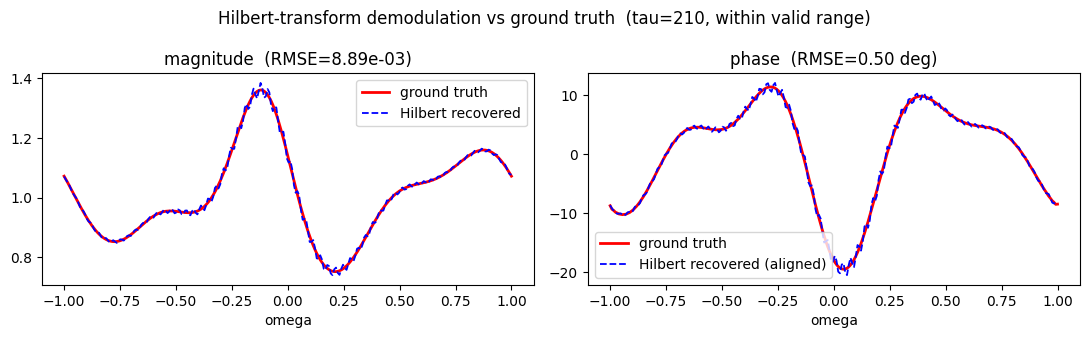

In [5]:
tau3 = (tau_min2 + tau_max2) / 2.0
S3 = spectral_interferogram(E_test2, E_ref2, omega2, tau3)
result3 = hilbert_demodulate(S3, omega2, tau3, E_ref=E_ref2)

mag_rmse3 = float(np.sqrt(np.mean((result3['magnitude_est'] - magnitude2) ** 2)))
offset3 = np.angle(np.mean(np.exp(1j * (phase2 - result3['phase_est']))))
aligned3 = np.angle(np.exp(1j * (result3['phase_est'] + offset3 - phase2)))
phase_rmse_deg3 = float(np.degrees(np.sqrt(np.mean(aligned3 ** 2))))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
axs[0].plot(omega2, magnitude2, 'r-', lw=2, label='ground truth')
axs[0].plot(omega2, result3['magnitude_est'], 'b--', lw=1.3, label='Hilbert recovered')
axs[0].set_title(f'magnitude  (RMSE={mag_rmse3:.2e})'); axs[0].legend(); axs[0].set_xlabel('omega')

axs[1].plot(omega2, np.degrees(phase2), 'r-', lw=2, label='ground truth')
axs[1].plot(omega2, np.degrees(result3['phase_est'] + offset3), 'b--', lw=1.3, label='Hilbert recovered (aligned)')
axs[1].set_title(f'phase  (RMSE={phase_rmse_deg3:.2f} deg)'); axs[1].legend(); axs[1].set_xlabel('omega')
plt.suptitle(f'Hilbert-transform demodulation vs ground truth  (tau={tau3:.0f}, within valid range)')
plt.tight_layout(); plt.show()

### The conjugate-ambiguity trap (a real bug, kept as a lesson)

Building this module the first time, using $e^{-i\omega\tau}$ in the forward
model and $e^{+i\omega\tau}$ in the demodulator (the "obvious" sign pairing)
silently recovered $\overline{E_{\rm test}}$ instead of $E_{\rm test}$: magnitude
came out fine (conjugation preserves $|E|$) but phase RMSE was $\sim\!103^\circ$
-- the signature of a wrapped sign flip, not noise ($180^\circ/\sqrt3\approx104^\circ$
is the RMS of a uniformly-wrapped phase error). Below: the SAME correct
demodulator, run with a $\tau$ chosen OUTSIDE `valid_tau_range` -- too small a
$\tau$ puts the fringe's quefrency peak inside the band the background filter
removes, corrupting recovery even with correct signs.

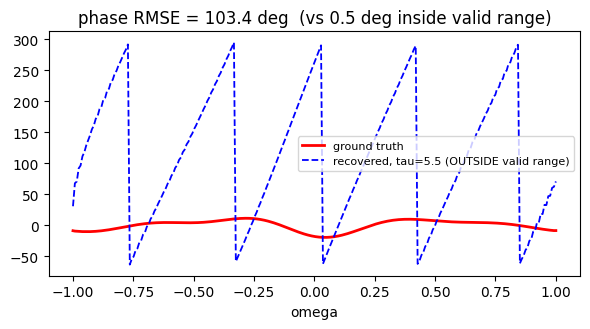

valid tau: 0.50 deg RMSE   |   too-small tau: 103.43 deg RMSE


In [6]:
bad_tau3 = tau_min2 / 4.0   # deliberately outside valid_tau_range
S3_bad = spectral_interferogram(E_test2, E_ref2, omega2, bad_tau3)
result3_bad = hilbert_demodulate(S3_bad, omega2, bad_tau3, E_ref=E_ref2)
offset3b = np.angle(np.mean(np.exp(1j * (phase2 - result3_bad['phase_est']))))
aligned3b = np.angle(np.exp(1j * (result3_bad['phase_est'] + offset3b - phase2)))
phase_rmse_bad = float(np.degrees(np.sqrt(np.mean(aligned3b ** 2))))

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(omega2, np.degrees(phase2), 'r-', lw=2, label='ground truth')
ax.plot(omega2, np.degrees(result3_bad['phase_est'] + offset3b), 'b--', lw=1.3,
        label=f'recovered, tau={bad_tau3:.1f} (OUTSIDE valid range)')
ax.set_title(f'phase RMSE = {phase_rmse_bad:.1f} deg  (vs {phase_rmse_deg3:.1f} deg inside valid range)')
ax.legend(fontsize=8); ax.set_xlabel('omega')
plt.tight_layout(); plt.show()
print(f"valid tau: {phase_rmse_deg3:.2f} deg RMSE   |   too-small tau: {phase_rmse_bad:.2f} deg RMSE")

## Part 4 -- RMSE distributions over many test profiles (reproduces the paper's Fig. 3)

The paper reports magnitude/phase RMSE distributions over a 300-profile test
set for the Hilbert baseline and two trained networks. Here: the SAME
distributional analysis for the Hilbert baseline alone (the trained-network
comparison is not reimplemented -- see Part 6's honesty note), over many
independently-generated causal test profiles.

**What would I actually measure in a lab?** Exactly this histogram, computed
over repeated single-shot acquisitions of different programmed test profiles.

**MATLAB equivalent:** `histogram(rmse_values)`.

**Questions to ask:** Is the distribution roughly consistent across profiles
(a tight distribution means the demodulator's accuracy doesn't depend much on
WHICH profile was measured), or are there occasional outliers?

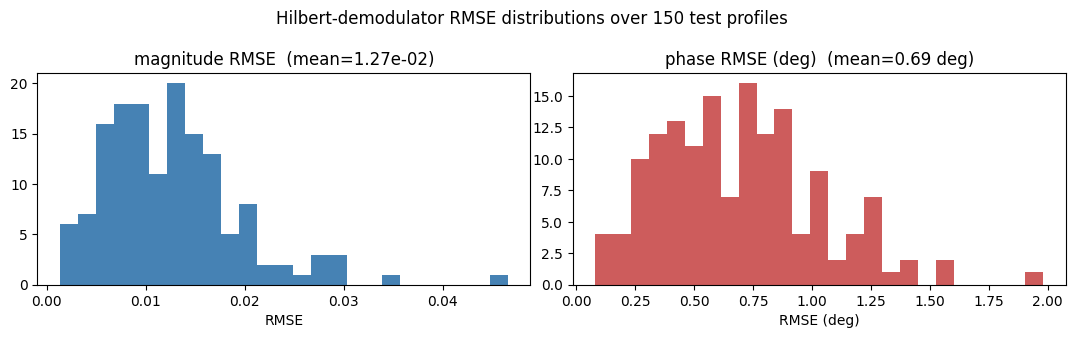

In [7]:
n_test4 = 150
rng4 = np.random.default_rng(7)
tau4 = (tau_min2 + tau_max2) / 2.0
mag_rmses4, phase_rmses4 = [], []
for _ in range(n_test4):
    m4, p4 = random_causal_profile(n2, rng4)
    Et4 = m4 * np.exp(1j * p4)
    S4 = spectral_interferogram(Et4, E_ref2, omega2, tau4)
    r4 = hilbert_demodulate(S4, omega2, tau4, E_ref=E_ref2)
    mag_rmses4.append(float(np.sqrt(np.mean((r4['magnitude_est'] - m4) ** 2))))
    off4 = np.angle(np.mean(np.exp(1j * (p4 - r4['phase_est']))))
    al4 = np.angle(np.exp(1j * (r4['phase_est'] + off4 - p4)))
    phase_rmses4.append(float(np.degrees(np.sqrt(np.mean(al4 ** 2)))))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
axs[0].hist(mag_rmses4, bins=25, color='steelblue')
axs[0].set_title(f'magnitude RMSE  (mean={np.mean(mag_rmses4):.2e})'); axs[0].set_xlabel('RMSE')
axs[1].hist(phase_rmses4, bins=25, color='indianred')
axs[1].set_title(f'phase RMSE (deg)  (mean={np.mean(phase_rmses4):.2f} deg)'); axs[1].set_xlabel('RMSE (deg)')
plt.suptitle(f'Hilbert-demodulator RMSE distributions over {n_test4} test profiles')
plt.tight_layout(); plt.show()

## Part 5 -- Digitizer quantization-noise robustness (reproduces the paper's Fig. 4)

The paper's central robustness claim: as digitizer resolution (ENOB, effective
number of bits) drops, the Hilbert baseline's accuracy degrades, while the
neural network stays accurate down to fewer bits -- "requiring only 4 bits of
ENOB compared to 6 bits ... before quantization noise reduces accuracy."
`demodulation_rmse_vs_enob` reproduces the STRUCTURE of this sweep for the
classical baseline alone (again, no trained network here).

**What would I actually measure in a lab?** Exactly this sweep, using an ADC's
actual selectable resolution modes (or a lower-resolution instrument
substituted in), same as the paper's Fig. 4 experiment.

**MATLAB equivalent:** MATLAB's `quantizer`/fixed-point toolbox for the ADC
model; the sweep itself is a simple `for` loop over ENOB values.

**Questions to ask:** Does RMSE plateau at high ENOB (yes -- once quantization
noise is small relative to other error sources, more bits stop helping, same
saturation behavior the paper's own Fig. 4 shows for both methods)? At what
ENOB does the classical baseline's error start growing sharply?

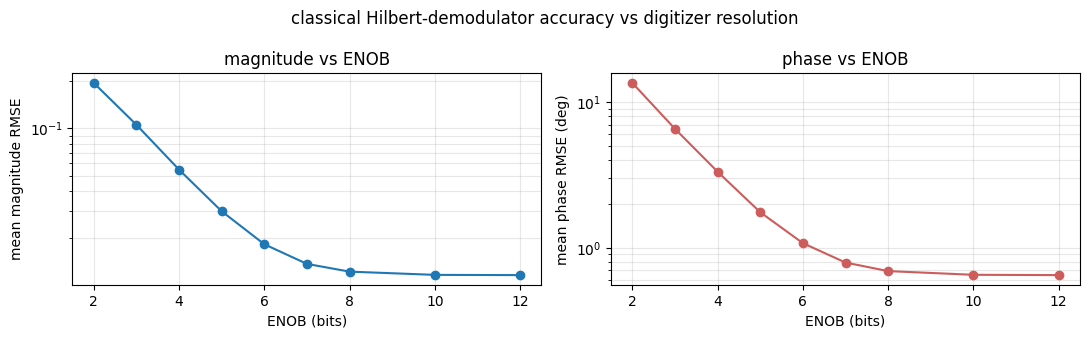

,ENOB,mag RMSE,phase RMSE (deg)
0,2.0,0.194138,13.562990
1,3.0,0.105270,6.561436
2,4.0,0.054631,3.326049
3,5.0,0.029721,1.752491
4,6.0,0.018346,1.074191
5,7.0,0.013766,0.790224
6,8.0,0.012295,0.690248
7,10.0,0.011726,0.651032
8,12.0,0.011685,0.647774


In [8]:
enob_values5 = np.array([2, 3, 4, 5, 6, 7, 8, 10, 12])
sweep5 = demodulation_rmse_vs_enob(n_trials=40, enob_values=enob_values5, n=n2, tau=tau4, rng_seed=3)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
axs[0].semilogy(sweep5['enob_values'], sweep5['mean_magnitude_rmse'], 'o-')
axs[0].set_xlabel('ENOB (bits)'); axs[0].set_ylabel('mean magnitude RMSE'); axs[0].set_title('magnitude vs ENOB')
axs[0].grid(alpha=0.3, which='both')
axs[1].semilogy(sweep5['enob_values'], np.degrees(sweep5['mean_phase_rmse_rad']), 'o-', color='indianred')
axs[1].set_xlabel('ENOB (bits)'); axs[1].set_ylabel('mean phase RMSE (deg)'); axs[1].set_title('phase vs ENOB')
axs[1].grid(alpha=0.3, which='both')
plt.suptitle('classical Hilbert-demodulator accuracy vs digitizer resolution')
plt.tight_layout(); plt.show()

df5 = pd.DataFrame({"ENOB": sweep5['enob_values'], "mag RMSE": sweep5['mean_magnitude_rmse'],
                     "phase RMSE (deg)": np.degrees(sweep5['mean_phase_rmse_rad'])})
display(df5)

## Part 6 -- Eq. (1): neural-network output size, and what this notebook does NOT reproduce

Eq. (1) of the paper sizes the network's output vector (concatenated
magnitude+phase spectra) from the time-stretch dispersion $D$, the profile's
wavelength range $\Delta\lambda$, and the digitizer sampling rate $F_s$:

$$n_{\rm output} = 2|D|\,\Delta\lambda\,F_s.$$

This reuses `dgs/photonic_vs_electronic_delay.py`'s already-verified
`dispersion_induced_delay_spread_s` ($=|D|\Delta\lambda$) rather than
re-deriving the group-delay-spread formula -- the same function
`dgs/sbir_portfolio.py`'s P9 proposal cites for its own time-multiplexing
budget.

**HONESTY NOTE -- what this notebook implements vs. what the paper claims:**
the paper's headline result is that a TRAINED NEURAL NETWORK outperforms this
classical Hilbert baseline, especially under fiber nonlinearity and
quantization noise. This notebook implements and validates the classical
baseline itself (Parts 3-5 above), NOT the trained network -- no PyTorch model
is trained here. `dgs/nn_spectral_regression.py` already has a numpy MLP
comparing NN vs. GS, but for the DIFFERENT two-dispersed-intensity setup, not
this paper's single-interferogram setup. Building an interferogram-to-(magnitude,
phase) regression network, trained and validated the way the paper's is, is a
natural next step but is explicitly NOT claimed as done here.

D=-1000.0 ps/nm, delta_lambda=20.0 nm, Fs=50 GSa/s
group-delay spread |D|*delta_lambda = 20000.0 ps
Eq. (1): n_output = 2*|D|*delta_lambda*Fs = 2,000 samples


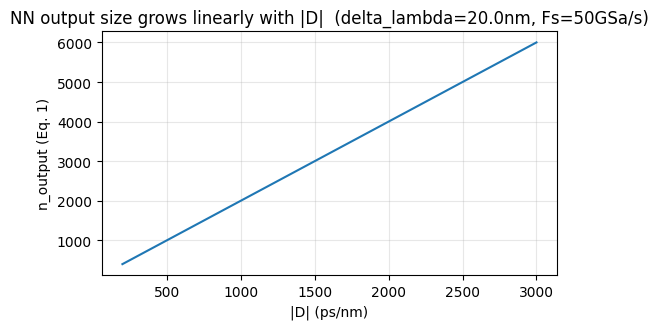

In [9]:
D_example = -1000.0    # ps/nm
delta_lambda_example = 20.0   # nm
Fs_example = 50e9              # 50 GSa/s

delay_s = dispersion_induced_delay_spread_s(D_example, delta_lambda_example)
n_out = spectral_regression_output_size(D_example, delta_lambda_example, Fs_example)
print(f"D={D_example} ps/nm, delta_lambda={delta_lambda_example} nm, Fs={Fs_example/1e9:.0f} GSa/s")
print(f"group-delay spread |D|*delta_lambda = {delay_s*1e12:.1f} ps")
print(f"Eq. (1): n_output = 2*|D|*delta_lambda*Fs = {n_out:,.0f} samples")

Ds = np.linspace(200, 3000, 40)
n_outs = [spectral_regression_output_size(-D, delta_lambda_example, Fs_example) for D in Ds]
plt.figure(figsize=(5.5, 3.4))
plt.plot(Ds, n_outs)
plt.xlabel('|D| (ps/nm)'); plt.ylabel('n_output (Eq. 1)')
plt.title(f'NN output size grows linearly with |D|  (delta_lambda={delta_lambda_example}nm, Fs={Fs_example/1e9:.0f}GSa/s)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Summary

| Quantity | This notebook | The paper |
|---|---|---|
| Forward model $S(\omega)$ | implemented, tested | experimental (real interferometer) |
| Causal test profiles | Bode log-mag/phase relation | Kramers-Kronig-constrained Waveshaper profiles |
| Classical demodulator | Hilbert transform, matched sign pair, `valid_tau_range` guard | same algorithm (section 2.4), the paper's baseline |
| RMSE distributions (Fig. 3) | reproduced for the classical baseline | classical baseline vs. two trained networks |
| ENOB robustness (Fig. 4) | reproduced for the classical baseline | classical baseline vs. trained network (4-bit vs 6-bit floor) |
| Eq. (1) output size | implemented, reuses existing repo formula | defines the paper's NN architecture |
| Trained neural network | **not implemented** | the paper's headline result |

Everything above is `dgs/spectral_interferometry.py` + `tests/test_spectral_interferometry.py`
(17 tests, including a regression test for the conjugate-ambiguity sign bug found
while building this).